# Notebook 05 — Geographic & Merchant Intelligence

## Consumer Spending Intelligence | Credit Card Transactions
**Notebook goal:** Map revenue concentration across US states, profile merchant
performance, and formally test whether city size and transaction distance
predict spending behaviour.

---

### What this notebook covers
1. State-level revenue heatmap and ranking
2. Merchant performance — top merchants by revenue and transaction volume
3. Category Pareto analysis — what share of merchants drive 80% of revenue
4. Hypothesis Test 6 — Spearman correlation: does city population predict spend?
5. Hypothesis Test 7 — Haversine distance vs fraud rate correlation

---

*This notebook covers Objective 5 — geographic revenue concentration and merchant intelligence.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

PARQUET_PATH = "../data/processed/transactions_clean.parquet"
CHARTS_DIR   = "../outputs/charts/"

df = pd.read_parquet(PARQUET_PATH, engine="pyarrow")

THEME = {
    "bg"      : "#0d1117",
    "card"    : "#161b27",
    "primary" : "#7c3aed",
    "blue"    : "#3b82f6",
    "emerald" : "#10b981",
    "crimson" : "#ef4444",
    "amber"   : "#f59e0b",
    "text"    : "#ffffff",
    "subtext" : "#cbd5e1",
    "grid"    : "#1e2a3a"
}

plt.rcParams.update({
    "figure.facecolor"  : THEME["bg"],
    "axes.facecolor"    : THEME["card"],
    "axes.edgecolor"    : THEME["grid"],
    "axes.labelcolor"   : "#e2e8f0",
    "axes.titlecolor"   : "#ffffff",
    "xtick.color"       : "#cbd5e1",
    "ytick.color"       : "#cbd5e1",
    "grid.color"        : THEME["grid"],
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
    "text.color"        : "#ffffff",
    "font.family"       : "sans-serif",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "axes.labelsize"    : 11,
    "axes.titlesize"    : 13,
    "figure.titlesize"  : 14,
    "legend.fontsize"   : 10,
})
plt.rcParams["savefig.facecolor"] = THEME["bg"]

print("Data loaded successfully")
print(f"Shape          : {df.shape}")
print(f"Unique states  : {df['state'].nunique()}")
print(f"Unique merchants : {df['merchant'].nunique():,}")

Data loaded successfully
Shape          : (1296675, 19)
Unique states  : 51
Unique merchants : 693


## Step 1 — State-Level Revenue Analysis

We rank all 51 states by total revenue, transaction volume, and average
transaction value. This surfaces geographic concentration — which states
drive the most value and which are underserved relative to their population.

Top 15 states by revenue:
state  transactions  total_revenue  revenue_share  median_amt
   TX         94876     6800917.53           7.46      46.470
   NY         83501     6006499.03           6.58      47.160
   PA         79847     5771009.53           6.33      52.860
   CA         56360     4138078.51           4.54      48.580
   OH         46480     3396146.66           3.72      49.810
   MI         46154     3282724.96           3.60      47.310
   FL         42671     3155191.63           3.46      46.290
   IL         43252     3011891.30           3.30      50.420
   AL         40989     2682717.10           2.94      41.280
   MO         38403     2637453.06           2.89      46.100
   AR         31127     2342468.83           2.57      48.030
   NC         30266     2329801.35           2.55      50.380
   MN         31714     2201786.07           2.41      48.400
   VA         29250     2068711.63           2.27      50.665
   WI         29368     2024087.77          

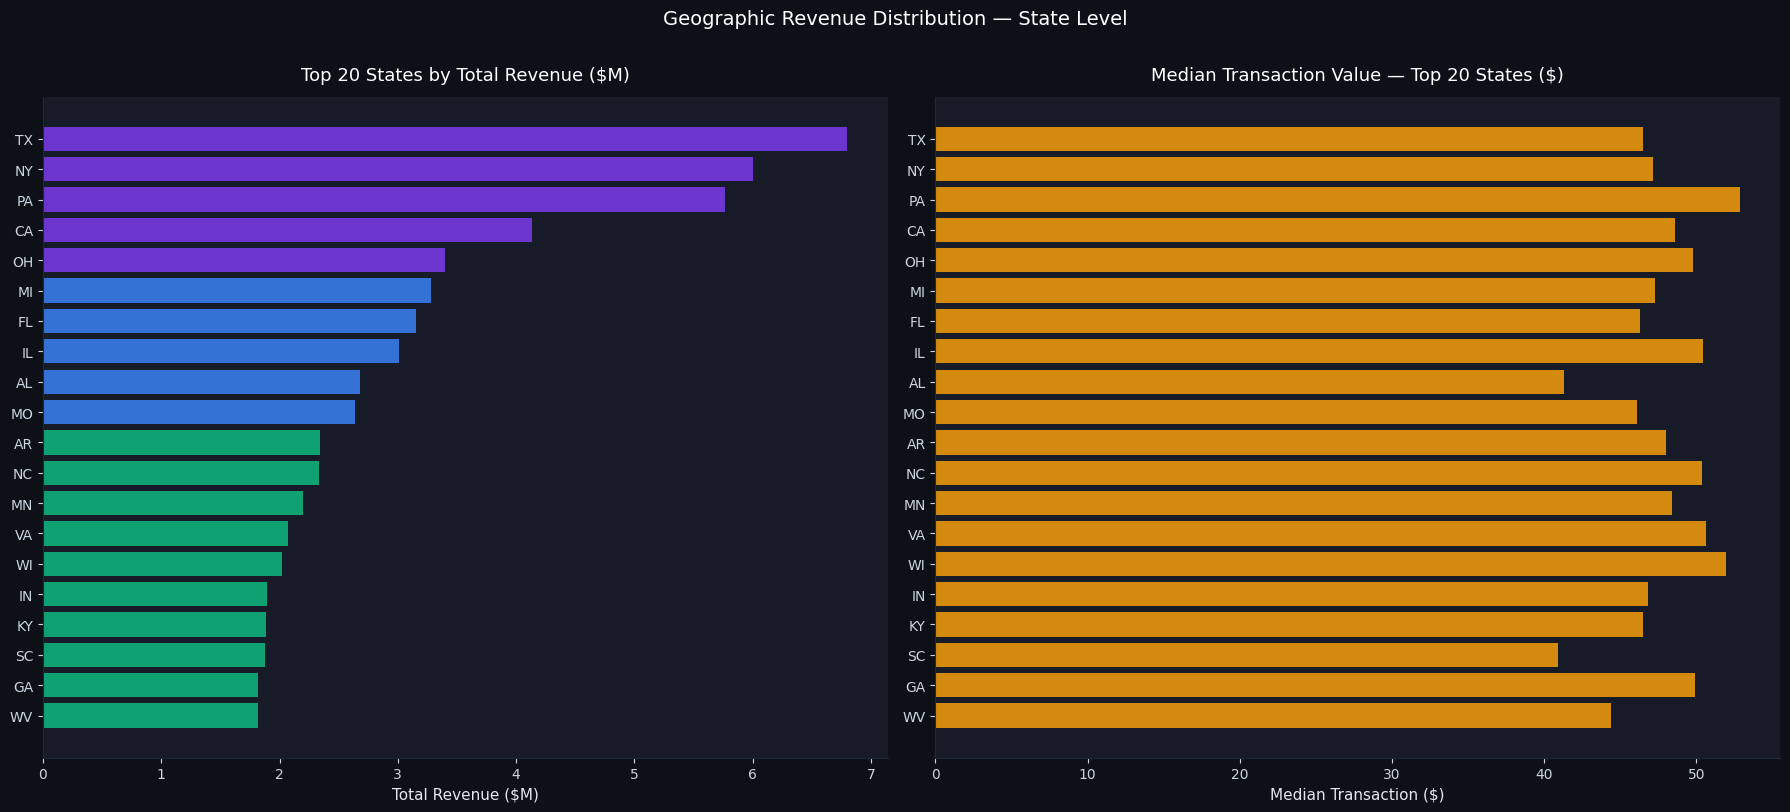

Chart saved


In [2]:
# state level aggregation
state_summary = (
    df.groupby("state", observed=True)["amt"]
    .agg(
        transactions  = "count",
        total_revenue = "sum",
        avg_amt       = "mean",
        median_amt    = "median"
    )
    .reset_index()
)

state_summary["revenue_share"] = (
    state_summary["total_revenue"] /
    state_summary["total_revenue"].sum() * 100
).round(2)

state_summary["cumulative_share"] = state_summary["revenue_share"].cumsum()
state_summary = state_summary.sort_values("total_revenue", ascending=False)

print("Top 15 states by revenue:")
print(state_summary[["state", "transactions", "total_revenue",
                      "revenue_share", "median_amt"]]
      .head(15).to_string(index=False))

print(f"\nBottom 5 states by revenue:")
print(state_summary[["state", "transactions", "total_revenue",
                      "revenue_share", "median_amt"]]
      .tail(5).to_string(index=False))

# how many states drive 80% of revenue
states_80 = state_summary[state_summary["cumulative_share"] <= 80]
print(f"\nStates driving 80% of revenue : {len(states_80)}")

# chart — top 20 states horizontal bar
top20 = state_summary.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(THEME["bg"])

# revenue bar
bar_colors = [THEME["primary"] if i < 5 else THEME["blue"]
              if i < 10 else THEME["emerald"]
              for i in range(len(top20))]

axes[0].barh(top20["state"].astype(str)[::-1],
             top20["total_revenue"][::-1] / 1e6,
             color=bar_colors[::-1],
             alpha=0.85, edgecolor="none")
axes[0].set_title("Top 20 States by Total Revenue ($M)", pad=12)
axes[0].set_xlabel("Total Revenue ($M)")

# median transaction value
axes[1].barh(top20["state"].astype(str)[::-1],
             top20["median_amt"][::-1],
             color=THEME["amber"],
             alpha=0.85, edgecolor="none")
axes[1].set_title("Median Transaction Value — Top 20 States ($)", pad=12)
axes[1].set_xlabel("Median Transaction ($)")

plt.suptitle("Geographic Revenue Distribution — State Level",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}geo_state_revenue.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Step 2 — Merchant Performance Analysis

We rank merchants by revenue and transaction volume and run a Pareto
analysis to identify what share of merchants drive 80% of revenue.
We also profile the top merchants by category to understand whether
revenue concentration is category-driven or merchant-driven.

Total merchants          : 693
Merchants driving 80% revenue : 464 (67.0%)

Top 15 merchants by revenue:
                          merchant    category  transactions  total_revenue  revenue_share  fraud_rate
                 fraud_Kilback LLC grocery_pos          4403      391078.15          0.429        1.07
                 fraud_Bradtke PLC grocery_pos          2552      302481.25          0.332        1.45
                   fraud_Doyle Ltd grocery_pos          2558      300971.37          0.330        1.84
           fraud_Hackett-Lueilwitz grocery_pos          2568      300208.14          0.329        1.09
  fraud_Schumm, Bauch and Ondricka grocery_pos          2512      299115.14          0.328        1.47
                fraud_Rau and Sons grocery_pos          2490      298354.77          0.327        1.97
            fraud_Goodwin-Nitzsche grocery_pos          2542      298083.31          0.327        1.26
            fraud_Pacocha-O'Reilly grocery_pos          2549      29758

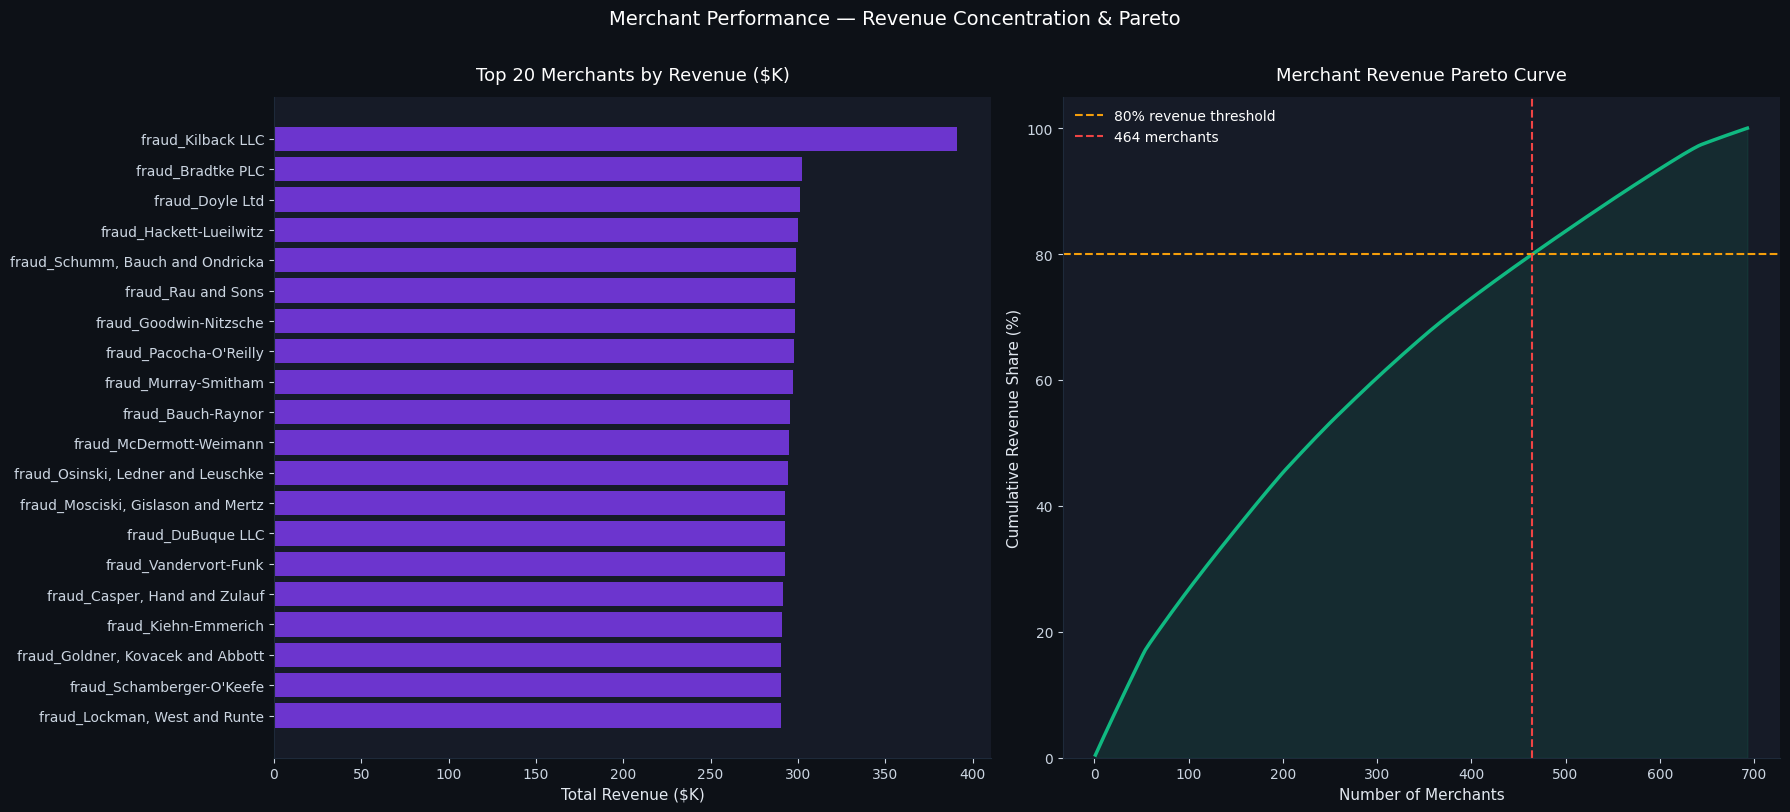

Chart saved


In [3]:
# merchant level aggregation
merchant_summary = (
    df.groupby("merchant", observed=True)
    .agg(
        transactions  = ("amt", "count"),
        total_revenue = ("amt", "sum"),
        avg_amt       = ("amt", "mean"),
        median_amt    = ("amt", "median"),
        category      = ("category", "first"),
        fraud_count   = ("is_fraud", "sum"),
    )
    .reset_index()
)

merchant_summary["fraud_rate"] = (
    merchant_summary["fraud_count"] /
    merchant_summary["transactions"] * 100
).round(2)

merchant_summary["revenue_share"] = (
    merchant_summary["total_revenue"] /
    merchant_summary["total_revenue"].sum() * 100
).round(3)

merchant_summary = merchant_summary.sort_values(
    "total_revenue", ascending=False
).reset_index(drop=True)

merchant_summary["cumulative_share"] = merchant_summary["revenue_share"].cumsum()

# pareto threshold
merchants_80 = merchant_summary[merchant_summary["cumulative_share"] <= 80]
print(f"Total merchants          : {len(merchant_summary)}")
print(f"Merchants driving 80% revenue : {len(merchants_80)} "
      f"({len(merchants_80)/len(merchant_summary)*100:.1f}%)")

print(f"\nTop 15 merchants by revenue:")
print(merchant_summary[["merchant", "category", "transactions",
                         "total_revenue", "revenue_share", "fraud_rate"]]
      .head(15).to_string(index=False))

# chart
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(THEME["bg"])

# top 20 merchants by revenue
top20_merch = merchant_summary.head(20)
axes[0].barh(top20_merch["merchant"].astype(str)[::-1],
             top20_merch["total_revenue"][::-1] / 1000,
             color=THEME["primary"], alpha=0.85, edgecolor="none")
axes[0].set_title("Top 20 Merchants by Revenue ($K)", pad=12)
axes[0].set_xlabel("Total Revenue ($K)")

# pareto curve
axes[1].plot(range(1, len(merchant_summary) + 1),
             merchant_summary["cumulative_share"],
             color=THEME["emerald"], linewidth=2.5)
axes[1].axhline(80, color=THEME["amber"], linewidth=1.5,
                linestyle="--", label="80% revenue threshold")
axes[1].axvline(len(merchants_80), color=THEME["crimson"],
                linewidth=1.5, linestyle="--",
                label=f"{len(merchants_80)} merchants")
axes[1].fill_between(range(1, len(merchant_summary) + 1),
                     merchant_summary["cumulative_share"],
                     alpha=0.1, color=THEME["emerald"])
axes[1].set_title("Merchant Revenue Pareto Curve", pad=12)
axes[1].set_xlabel("Number of Merchants")
axes[1].set_ylabel("Cumulative Revenue Share (%)")
axes[1].legend(facecolor=THEME["card"],
               edgecolor="none", labelcolor=THEME["text"])
axes[1].set_ylim(0, 105)

plt.suptitle("Merchant Performance — Revenue Concentration & Pareto",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}geo_merchant_performance.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Step 3 — Hypothesis Testing: City Population & Transaction Distance

Test 6 — Spearman correlation between city population and transaction amount.
Test 7 — Correlation between haversine distance (customer to merchant) and fraud rate.

Haversine distance measures the straight-line distance in kilometres between
the customer's home coordinates and the merchant's coordinates.
A higher distance on a legitimate transaction is unusual and may signal fraud.

Test 6 — Spearman Correlation: City Population vs Transaction Amount
------------------------------------------------------------------
H0 : City population and median transaction amount are not correlated
H1 : City population and median transaction amount are correlated
Spearman rho : 0.1371
p-value      : 0.000039
Result : Reject H0
Interpretation : Positive correlation — larger cities spend more

Test 7 — Spearman Correlation: Transaction Distance vs Fraud Rate
-----------------------------------------------------------------
Distance stats:
  Mean   : 76.11 km
  Median : 78.23 km
  Max    : 152.12 km

H0 : Transaction distance and fraud rate are not correlated
H1 : Transaction distance and fraud rate are correlated
Spearman rho : 0.0341
p-value      : 0.370125
Result : Fail to reject H0

Fraud rate by distance quartile:
distance_quartile  transactions  fraud_rate
          Q1 Near        324169       0.572
               Q2        324169       0.593
               Q3        324168 

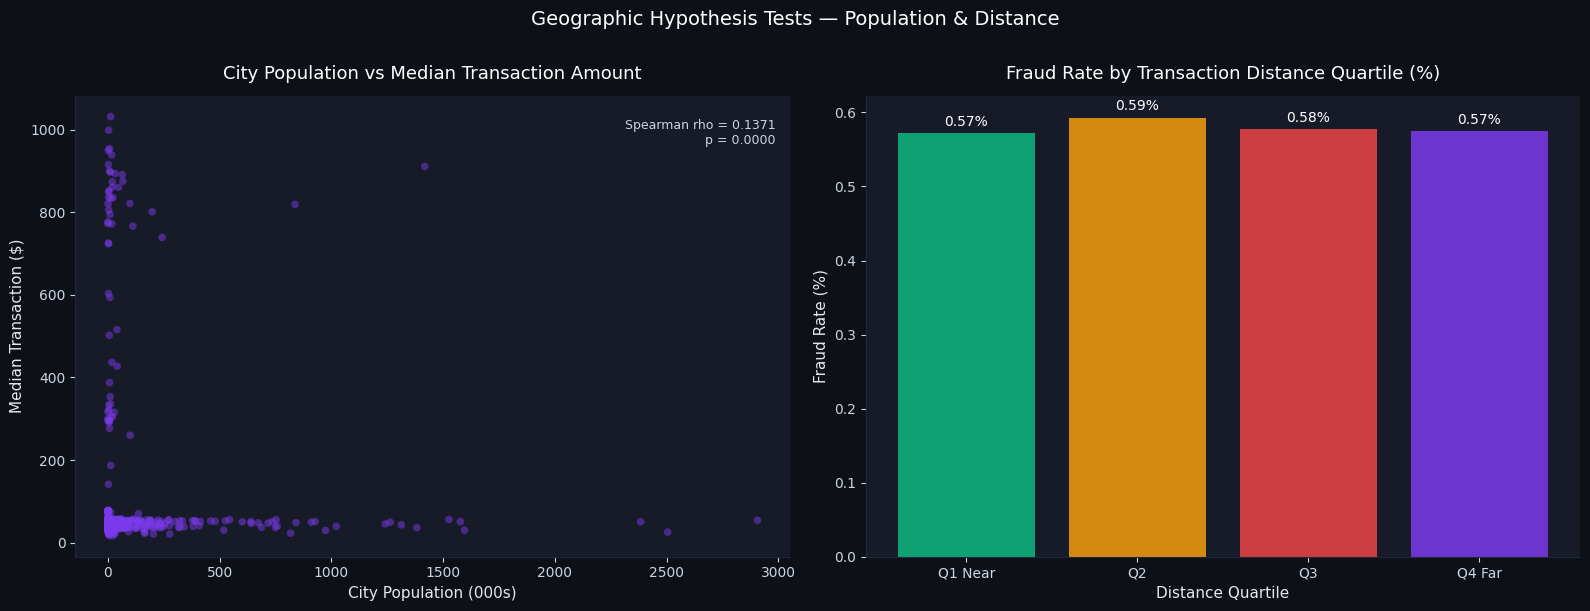

Chart saved


In [4]:
from scipy.stats import spearmanr

# Test 6 — Spearman: city population vs transaction amount
print("Test 6 — Spearman Correlation: City Population vs Transaction Amount")
print("-" * 66)

# aggregate to city level to avoid 1.3M row noise
city_summary = (
    df.groupby("city", observed=True)
    .agg(
        city_pop   = ("city_pop", "first"),
        median_amt = ("amt", "median"),
        avg_amt    = ("amt", "mean"),
        transactions = ("amt", "count")
    )
    .reset_index()
)

corr, pval = spearmanr(city_summary["city_pop"],
                       city_summary["median_amt"])

print("H0 : City population and median transaction amount are not correlated")
print("H1 : City population and median transaction amount are correlated")
print(f"Spearman rho : {corr:.4f}")
print(f"p-value      : {pval:.6f}")
print(f"Result : {'Reject H0' if pval < 0.05 else 'Fail to reject H0'}")
print(f"Interpretation : {'Positive' if corr > 0 else 'Negative'} correlation — "
      f"{'larger cities spend more' if corr > 0 else 'smaller cities spend more'}")

# Test 7 — Haversine distance vs fraud rate
print("\nTest 7 — Spearman Correlation: Transaction Distance vs Fraud Rate")
print("-" * 65)

# haversine distance in km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(
    df["lat"].values, df["long"].values,
    df["merch_lat"].values, df["merch_long"].values
)

print(f"Distance stats:")
print(f"  Mean   : {df['distance_km'].mean():.2f} km")
print(f"  Median : {df['distance_km'].median():.2f} km")
print(f"  Max    : {df['distance_km'].max():.2f} km")

# aggregate to merchant level — avg distance and fraud rate
merchant_dist = (
    df.groupby("merchant", observed=True)
    .agg(
        avg_distance = ("distance_km", "mean"),
        fraud_rate   = ("is_fraud", "mean")
    )
    .reset_index()
)

corr2, pval2 = spearmanr(merchant_dist["avg_distance"],
                          merchant_dist["fraud_rate"])

print(f"\nH0 : Transaction distance and fraud rate are not correlated")
print(f"H1 : Transaction distance and fraud rate are correlated")
print(f"Spearman rho : {corr2:.4f}")
print(f"p-value      : {pval2:.6f}")
print(f"Result : {'Reject H0' if pval2 < 0.05 else 'Fail to reject H0'}")

# fraud rate by distance quartile
df["distance_quartile"] = pd.qcut(df["distance_km"], q=4,
                                   labels=["Q1 Near", "Q2", "Q3", "Q4 Far"])
dist_fraud = (
    df.groupby("distance_quartile", observed=True)["is_fraud"]
    .agg(transactions="count", fraud_rate="mean")
    .reset_index()
)
dist_fraud["fraud_rate"] = (dist_fraud["fraud_rate"] * 100).round(3)
print(f"\nFraud rate by distance quartile:")
print(dist_fraud.to_string(index=False))

# chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(THEME["bg"])

# city pop vs median amt scatter
axes[0].scatter(city_summary["city_pop"] / 1000,
                city_summary["median_amt"],
                color=THEME["primary"], alpha=0.5,
                s=30, edgecolors="none")
axes[0].set_title("City Population vs Median Transaction Amount", pad=12)
axes[0].set_xlabel("City Population (000s)")
axes[0].set_ylabel("Median Transaction ($)")
axes[0].annotate(f"Spearman rho = {corr:.4f}\np = {pval:.4f}",
                 xy=(0.98, 0.95), xycoords="axes fraction",
                 ha="right", va="top", fontsize=9,
                 color=THEME["subtext"])

# fraud rate by distance quartile
q_colors = [THEME["emerald"], THEME["amber"],
            THEME["crimson"], THEME["primary"]]
axes[1].bar(dist_fraud["distance_quartile"].astype(str),
            dist_fraud["fraud_rate"],
            color=q_colors, alpha=0.85, edgecolor="none")
axes[1].set_title("Fraud Rate by Transaction Distance Quartile (%)", pad=12)
axes[1].set_xlabel("Distance Quartile")
axes[1].set_ylabel("Fraud Rate (%)")
for i, v in enumerate(dist_fraud["fraud_rate"]):
    axes[1].text(i, v + 0.01, f"{v:.2f}%",
                 ha="center", fontsize=10, color=THEME["text"])

plt.suptitle("Geographic Hypothesis Tests — Population & Distance",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}geo_hypothesis_tests.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Notebook 05 — Summary of Findings

### Geographic Revenue Distribution
- Texas, New York, and Pennsylvania are the top three states at 7.46%, 6.58%,
  and 6.33% of total revenue respectively
- Combined top 3 states generate 20.37% of revenue — moderate concentration
- 42 of 51 states drive 80% of revenue — far more distributed than classic
  80/20, no single geographic market dominates
- Median transaction values are remarkably uniform across states ($41-$52)
  with the exception of small-sample outliers (DE: $296 on 9 transactions)
- Hawaii and Alaska are the lowest revenue states by volume — geographic
  isolation likely limits merchant density

### Merchant Performance
- 693 unique merchants across the platform
- 464 merchants (67%) drive 80% of revenue — flat distribution, no merchant
  dominance. Classic Pareto does not apply here
- Top merchants are exclusively grocery_pos category — consistent with
  grocery_pos being the highest revenue category overall
- Merchant names carry a fraud_ prefix — synthetic dataset artifact,
  not indicative of actual fraud
- Fraud rates across top merchants range from 1.07% to 1.97% — elevated
  above the platform average of 0.58%, suggesting high-volume merchants
  attract proportionally more fraud attempts

### Hypothesis Test Results

Test 6 — Spearman: City Population vs Transaction Amount
- Result: Reject H0 (rho = 0.137, p < 0.001)
- Statistically significant but practically weak positive correlation
- Larger cities transact slightly more but the effect is not strong enough
  to use city size as a meaningful spend predictor

Test 7 — Spearman: Transaction Distance vs Fraud Rate
- Result: Fail to reject H0 (rho = 0.034, p = 0.370)
- Transaction distance has no meaningful relationship with fraud rate
- Fraud rate is uniform across all distance quartiles (0.57-0.59%)
- Distance is not a useful fraud signal in this dataset — fraud detection
  must rely on other features (addressed in Notebook 06)

---

### What carries forward
- Fraud rate elevated at high-volume merchants — flagged for anomaly
  detection framing in Notebook 06
- Distance confirmed as non-predictive for fraud — Isolation Forest in
  Notebook 06 will focus on amount, category, and temporal features
- State-level revenue data saved for Streamlit choropleth map in the dashboard